# makeshift — chemical shift re-referencing

BMRB shifts are sometimes mis-referenced: a constant offset shifts every peak of a given nucleus. `ChemicalShifts.reref` corrects this in place using one of two methods:

- **PANAV** — secondary-structure-based reference distributions (Wang & Wishart 2005)
- **LACS** — linear regression of secondary shifts vs CSI; covers CA, CB, C′, N, HN (Wang & Markley 2009)

In [1]:
import makeshift as ms
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Re-reference an entry

`reref` updates `cs.data` in place and records the per-atom offsets (`reref_offsets`) and success flags (`reref_check`).

In [6]:
cs = ms.ChemicalShifts.from_bmrb(6586)
before = cs.data.copy()        # keep the originals to compare against

cs.reref('panav')
print('offsets:', {k: round(v, 4) for k, v in cs.reref_offsets.items() if v is not None})
print('per-atom success:', cs.reref_check)

offsets: {'N': -4.922, 'CA': -5.1153, 'C': -5.1064}
per-atom success: {'N': True, 'CA': True, 'CB': False, 'C': True}


## 2. Before vs after

The offset shifts a whole nucleus's distribution. Original (dotted) vs corrected (solid).

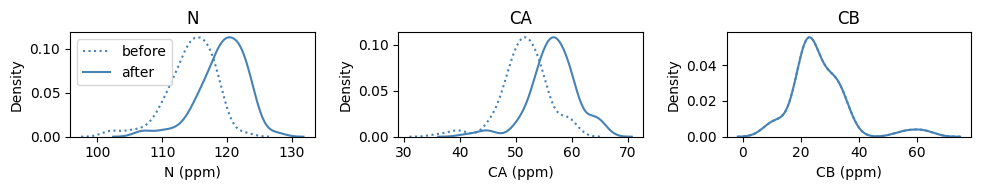

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(10, 2))
for ax, atom in zip(axes, ['N', 'CA', 'CB']):
    sns.kdeplot(before[before['Atom_ID'] == atom]['Val'], ax=ax, ls=':', color='steelblue', label='before')
    sns.kdeplot(cs.data[cs.data['Atom_ID'] == atom]['Val'], ax=ax, color='steelblue', label='after')
    ax.set_title(atom); ax.set_xlabel(f'{atom} (ppm)')
axes[0].legend(); plt.tight_layout()

## 3. LACS vs PANAV

The two methods can disagree. Compare their offsets across a few entries.

In [8]:
rows = []
for bmrb_id in [4527, 6586, 4150]:
    for method in ['panav', 'lacs']:
        cs = ms.ChemicalShifts.from_bmrb(bmrb_id)
        cs.reref(method)
        for atom in ['N', 'CA', 'CB']:
            rows.append(dict(bmrb_id=bmrb_id, method=method, atom=atom,
                             offset=cs.reref_offsets.get(atom)))

pd.DataFrame(rows).pivot_table(index=['bmrb_id', 'atom'], columns='method', values='offset')

method            lacs     panav
bmrb_id atom                    
4150    CA   -0.705335 -0.597827
        CB   -0.424287       NaN
        N     0.000000 -1.088168
4527    CA    0.402784  0.185763
        CB    0.402783  0.335755
        N     1.075579 -0.994706
6586    CA   -7.060243 -5.115310
        CB   -7.118230       NaN
        N    -3.994060 -4.922000

## 4. Re-reference at load time

Pass `reref=` to `from_bmrb` to correct on the way in, then use the shifts downstream (CSI, HSQC, peaklists).

In [5]:
cs = ms.ChemicalShifts.from_bmrb(31107, reref='panav', calc_csi=True)
print('offsets:', {k: round(v, 3) for k, v in cs.reref_offsets.items() if v is not None})
cs.data.head()

offsets: {'N': -0.66, 'CA': 0.199, 'CB': 0.638}


,Entity_ID,Seq_ID,Auth_seq_ID,Comp_ID,Atom_ID,Atom_type,Val,ChemShift_ID,csi_raw,csi
0,1,1,1,MET,H,H,7.941,assigned_chemical_shifts_1,-0.360723,0.0
1,1,1,1,MET,HA,H,4.678,assigned_chemical_shifts_1,-0.360723,0.0
2,1,1,1,MET,HB2,H,2.046,assigned_chemical_shifts_1,-0.360723,0.0
3,1,1,1,MET,HG2,H,2.463,assigned_chemical_shifts_1,-0.360723,0.0
4,1,1,1,MET,HG3,H,2.436,assigned_chemical_shifts_1,-0.360723,0.0
